29 C in box with -10C ambient, 13W nominal heater and 4.25-4.5W startup idle.

- 40C deltaT -> 2.3C/W


- TECs on to 19 C
    - 1 A, brief peak @ 2.6 A
- Lasers on to 100%
    - 1.95 A, peak @ ~2.8 A

Operating:
- 4.25 - 10W
- Expect 9.8 - 23 C above ambient
- Dome -10 - 10 -> 0 - 33 steady-state temp w/o heater
- Need 17C/7.5 W of heating idle, 4C/1.75W running in cold dome, idle heater leaves 10C margin in box
- Need no heating in warm dome, 7C thermal margin in box with 10C dome
- Some heating needed at idle below 7.25 C (strictly 5.25C)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ait.photonic_testing.photonic_testing import *
MODBUS_PORT='/dev/tty.usbserial-B003T6PZ'
LASER_ADDRESSES = {"1028": 5,
                   "1270": 6,
                   "yj1430": 4,
                   "hk1430": 3,
                   "1510": 1,
                   "2330": 2}

In [2]:
def plot_tuning_data(laser_props, x, tset=None, pid=None):
    pwr, wave = Laser.compute_power_and_wavelength(laser_props, x['tec_temp_c'], x['diode_current_ma'])
    t = x["t_s"]

    # --- Plot 1: Electrical (2 y-axes) ---
    fig1, ax = plt.subplots(3,1, figsize=(10, 4*3))
    ax_v, ax_p, ax_t = ax[0], ax[1], ax[2]

    # Left axis: voltage
    l1 = ax_v.plot(t, x["diode_voltage_v"], color="tab:blue", label="Diode Voltage (V)")
    l3 = ax_v.plot(t, x["tec_voltage_v"], color="tab:cyan", label="TEC Voltage (V)")
    ax_v.set_xlabel("Time (s)")
    ax_v.set_ylabel("Voltage (V)", color="tab:blue")
    ax_v.tick_params(axis="y", labelcolor="tab:blue")
    ax_v.grid(True, alpha=0.3)

    # Right axis: current
    ax_i = ax_v.twinx()
    l2 = ax_i.plot(t, x["diode_current_ma"], color="tab:orange", label="Diode Current (mA)")
    l4 = ax_i.plot(t, x["tec_current_a"]*1000,'.', color="tab:red", label="TEC Current (mA)")
    ax_i.set_ylabel("Current (mA)", color="tab:orange")
    ax_i.tick_params(axis="y", labelcolor="tab:orange")
    # ax_i.set_xlim(0,10)

    # Combined legend
    lines = l1 + l2 + l4 + l3
    labels = [ln.get_label() for ln in lines]
    ax_v.legend(lines, labels, loc="best")
    ax_v.set_xlim(0,None)
    # fig1.tight_layout()


    # --- Plot 2: Optical (2 y-axes) ---
    # fig2, ax_p = plt.subplots(figsize=(10, 4))

    # Left axis: optical power
    l3 = ax_p.plot(t, pwr, color="tab:green", label="Optical Power")
    ax_p.set_xlabel("Time (s)")
    ax_p.set_ylabel("Optical Power", color="tab:green")
    ax_p.tick_params(axis="y", labelcolor="tab:green")
    ax_p.grid(True, alpha=0.3)

    # Right axis: wavelength
    ax_w = ax_p.twinx()
    l4 = ax_w.plot(t, wave, color="tab:red", label="Wavelength")
    ax_w.set_ylabel("Wavelength", color="tab:red")
    ax_w.tick_params(axis="y", labelcolor="tab:red")

    # Combined legend
    lines = l3 + l4
    labels = [ln.get_label() for ln in lines]
    ax_p.legend(lines, labels, loc="best")
    ax_p.set_xlim(0,None)

    plt.sca(ax_t)
    # plt.subplots(figsize=(10, 4))
    plt.plot(t, x['tec_temp_c'], label='TEC Temp')
    if tset is not None: plt.axhline(tset, label='Setpoint')
    plt.title('Measured Temp'+ '' if not pid else f' PID: {pid}')
    plt.axhline(15,linestyle='--', alpha=0.5)
    plt.axhline(40,linestyle='--', alpha=0.5)
    plt.xlabel("Time (s)")
    plt.ylabel('Temp (C)')
    plt.ylim(10,45)
    plt.xlim(0,None)
    plt.legend(loc="best")
    plt.tight_layout()

    fig1.tight_layout()
    plt.show()

### Overview

See `ait/photonic_testing.py` for `Laser` and `LaserProperties` along with the specific limits of the individual laser diodes.


## Initialize all the diodes

Running this cell will create the `lasers` dictionary with a `Laser` for each laser.

In [3]:
names = tuple(LASER_ADDRESSES.keys())
lasers = {name: Laser(name, address=LASER_ADDRESSES[name], MODBUS_PORT=MODBUS_PORT) for name in names}

Raw ID from register: 0x1113
🆔 Found device ID: 4371
📦 Loaded device configuration.
Raw ID from register: 0x1113
🆔 Found device ID: 4371
📦 Loaded device configuration.
Raw ID from register: 0x1113
🆔 Found device ID: 4371
📦 Loaded device configuration.
Raw ID from register: 0x1113
🆔 Found device ID: 4371
📦 Loaded device configuration.
Raw ID from register: 0x1113
🆔 Found device ID: 4371
📦 Loaded device configuration.
Raw ID from register: 0x1113
🆔 Found device ID: 4371
📦 Loaded device configuration.


In [4]:
for l in lasers.values(): l.shutdown()

[25.44, 24.69, 25.07, 24.93, 24.16, 24.82]

In [4]:
lns = ['2330']
lns = lasers.keys()
for ln in lns:
    self=lasers[ln]
    # self.device.stop_device()
    # self.device.set_tec_temperature(19)
    # self.device.set_current(0)
    # self.device.start_tec()
    self.status(verbose=True)
    # self.device.start_device()
[l.device.get_tec_temperature_measured() for l in lasers.values()]

Raw ID from register: 0x1113
Laser Name: '1028'
Device ID: 4371
Serial Number: 8229
Operation started: False
 Raw State: 0xf5
 Current Set Internal: True
 Enable Internal: True
 External NTC Denied: True
 Interlock Denied: True
 Interlock State: 0x2
 Interlock: True
 External NTC Interlock: False
Voltage: 0.0
Current (min-max): 0.00 (0.00-250.00)
Protection Threshold: 264.3
Driver Max Current: 250.0
Current Set Calibration: 100.0
Frequency: 0.0
Duration: 1.0
TEC Started: True
 TEC Temperature Setpoint: 19.0
 TEC Temperature: 18.94
 TEC Voltage: 0.2
 TEC Current Limit: 1.2
 TEC Current: 0.0
 TEC Error: False
 TEC Self-heat: False
 TEC PID: (20, 1000, 1000)
 TEC NTC Coefficient: 3988.0
 TEC Raw State: 0x16
 TEC Set Internal: True
 TEC Enable Internal: True
LD Overcurrent: False
LD Overheat: False
Raw ID from register: 0x1113
Laser Name: '1270'
Device ID: 4371
Serial Number: 8228
Operation started: False
 Raw State: 0xf5
 Current Set Internal: True
 Enable Internal: True
 External NTC Den

[18.95, 19.0, 19.0, 19.0, 18.99, 19.02]

In [41]:
# ln='1028'
# lasers[ln].device.start_tec()
# lasers[ln].status(verbose=False)
# print('\nStopping ...\n')
# lasers[ln].device.stop_device()
# print('\nStopped ...\n')
# lasers[ln].status(verbose=False)
# print('\nEnable interlock ...\n')
# lasers[ln].device.enable_interlock()
# print('\nInterlocked ...\n')
# lasers[ln].status(verbose=False)
# lasers[ln].device.start_tec()
# lasers[ln].device.start_device()
# print('\nDisable interlock ...\n')
# lasers[ln].device.disable_interlock()
# print('\nClear ...\n')
# lasers[ln].status(verbose=False)

In [7]:
lns = lasers.keys()
for ln in lns:
    self=lasers[ln]
    # self.set_current_as_percent(1, autooff=0)
    self.status(verbose=False)

Laser Name: '1028'
Operation started: False
Voltage: 0.0
Current (min-max): 0.00 (0.00-250.00)
Current Set Calibration: 100.0
TEC Started: False
 TEC Temperature Setpoint: 19.0
 TEC Temperature: 25.43
 TEC Voltage: 0.0
 TEC Current Limit: 1.2
 TEC Current: 0.0
 TEC Error: False
 TEC Self-heat: False
LD Overcurrent: False
LD Overheat: False
Laser Name: '1270'
Operation started: False
Voltage: 0.0
Current (min-max): 0.00 (0.00-60.00)
Current Set Calibration: 100.0
TEC Started: False
 TEC Temperature Setpoint: 19.0
 TEC Temperature: 24.68
 TEC Voltage: 0.0
 TEC Current Limit: 1.0
 TEC Current: 0.0
 TEC Error: False
 TEC Self-heat: False
LD Overcurrent: False
LD Overheat: False
Laser Name: '1430'
Operation started: False
Voltage: 0.0
Current (min-max): 0.00 (0.00-60.00)
Current Set Calibration: 100.0
TEC Started: False
 TEC Temperature Setpoint: 19.0
 TEC Temperature: 25.06
 TEC Voltage: 0.0
 TEC Current Limit: 1.0
 TEC Current: 0.0
 TEC Error: False
 TEC Self-heat: False
LD Overcurrent: F

In [23]:
ln='1028'
lasers[ln].device.set_tec_temperature(19)
lasers[ln].device.start_tec()
lasers[ln].status(verbose=True)
data = lasers[ln].monitor_diode(duration_s=6, cadence_hz=10)

Laser Name: '1028'
Raw ID from register: 0x1113
Device ID: 4371
Serial Number: 8229
Operation started: False
 Raw State: 0xf5
 Current Set Internal: True
 Enable Internal: True
 External NTC Denied: True
 Interlock Denied: True
 Interlock State: 0x2
 Interlock: True
 External NTC Interlock: False
Voltage: 0.0
Current (min-max): 0.00 (0.00-250.00)
Protection Threshold: 264.1
Driver Max Current: 250.0
Current Set Calibration: 100.0
Frequency: 0.0
Duration: 1.0
TEC Started: True
 TEC Temperature Setpoint: 19.0
 TEC Temperature: 33.71
 TEC Voltage: 2.2
 TEC Current Limit: 1.2
 TEC Current: 1.2
 TEC Error: False
 TEC Self-heat: False
 TEC PID: (20, 1000, 1000)
 TEC NTC Coefficient: 3988.0
 TEC Raw State: 0x16
 TEC Set Internal: True
 TEC Enable Internal: True
LD Overcurrent: False
LD Overheat: False


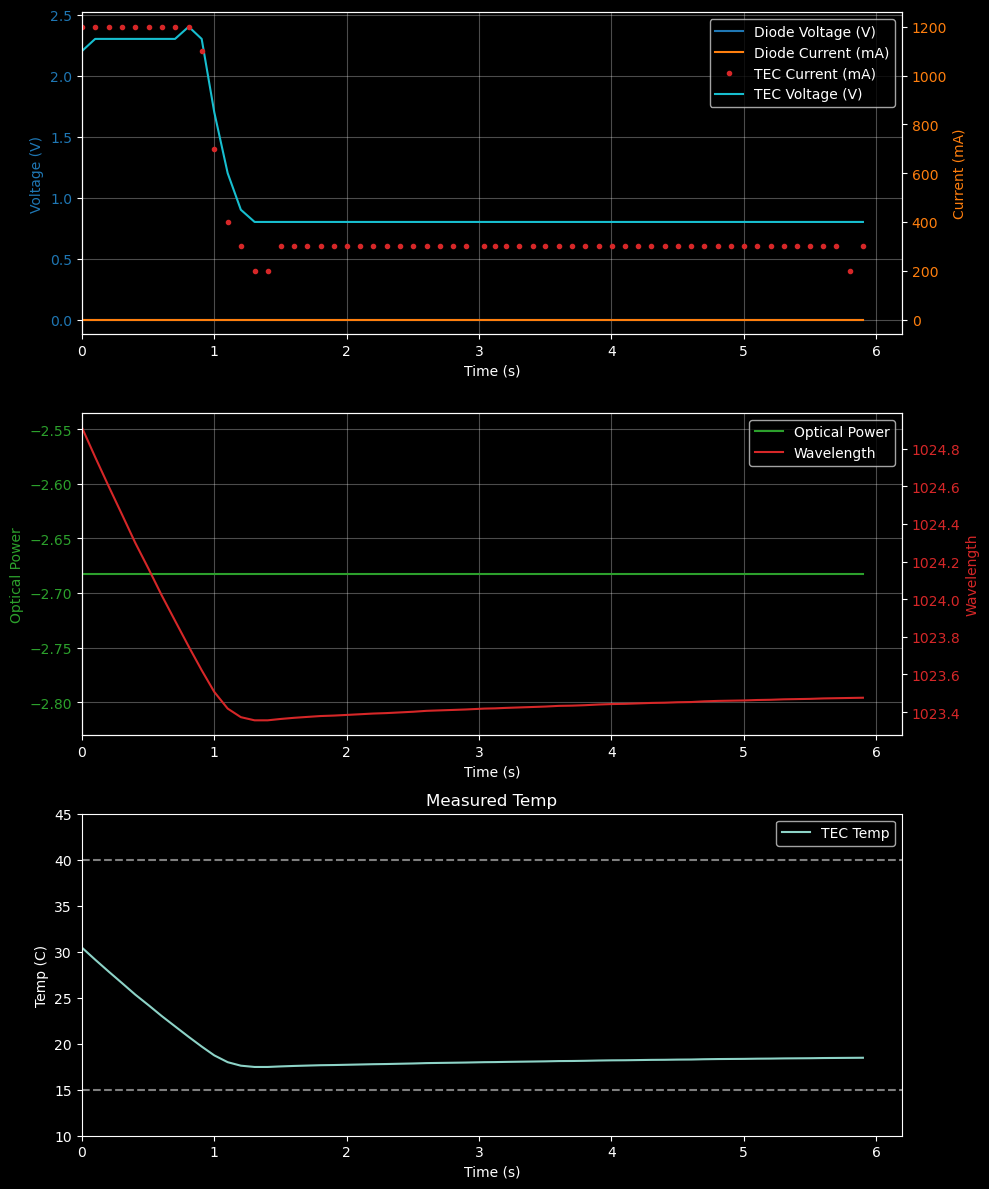

In [25]:
x=data.get_data()
plot_tuning_data(lasers[ln].laser_properties, x)

### Turn on a laser

In [6]:
lasers['2330'].set_current_as_percent(1, autooff=0)

RuntimeError: Laser not ready to operate, try calling disable_interlock_and_cool() or status()

Look at the status of one of them. It seems that the TEC status isn't polling well, but the temp changes.

In [9]:
lasers['2330'].status(verbose=False)

Laser Name: '2330'
Operation started: False
Voltage: 0.4
Current (min-max): 0.00 (0.00-120.00)
Current Set Calibration: 100.0
TEC Started: False
 TEC Temperature Setpoint: 15.0
 TEC Temperature: 12.22
 TEC Voltage: 6553.2
 TEC Current Limit: 1.2
 TEC Current: 0.0
 TEC Error: False
 TEC Self-heat: False
LD Overcurrent: False
LD Overheat: True


In [10]:
lasers['2330'].tune_wavelength(.01,2329*u.nm, maximum_power_shift=.1, autooff=0, apply=False)

RuntimeError: Laser not ready to operate, try calling disable_interlock_and_cool() or status()

In [16]:
data = lasers['2330'].tune_and_monitor(.01,2327*u.nm, duration_s=5, maximum_power_shift=.1, autooff=0, apply=1, cadence_hz=10)

Programming limits for 2330, Maiman driver: S/N 8226...
Requested tuning 2329.810 nm to 2327.000 nm at 1.0±10.00% flux.
    TEC Temp: 17.0 deg_C (current 34.34 deg_C), resulting dl from nominal -0.960 nm.
    Drive current: 25.851 mA->24.9 mA, resulting dl -1.426 nm.
    Optical Power: 0.00 mW
    Laser power difference from request: -0.03 mW
    Wavelength difference from request: 0.989 nm
    Note drive accuracy: 0.021 nm


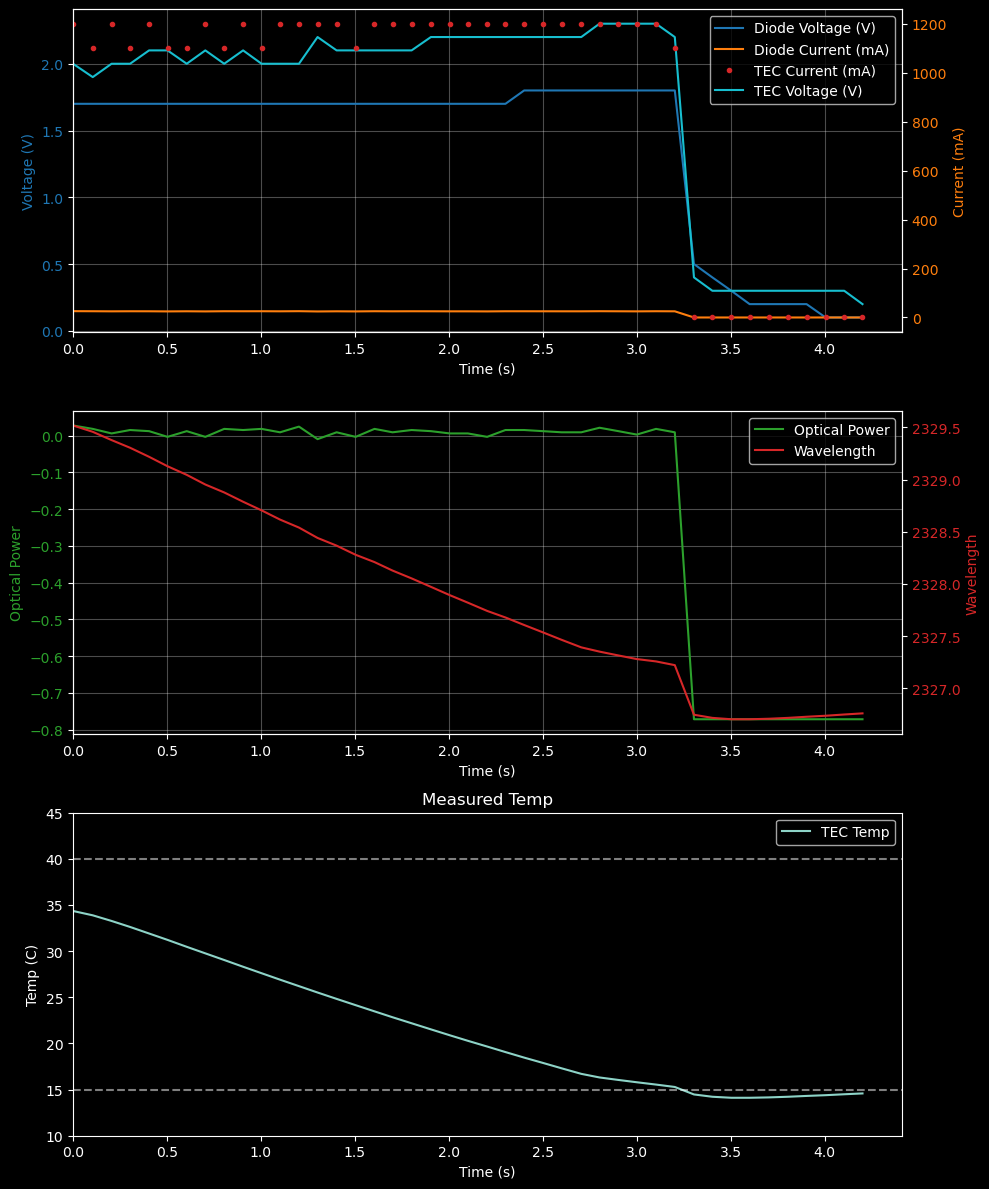

In [17]:
x=data.get_data()
plot_tuning_data(lasers['2330'].laser_properties, x)

In [6]:
lasers['2330'].status(verbose=False)

Laser Properties Name: 2330
Operation started: True
Voltage: 3.2
Current (min-max): 120.00 (0.00-120.00
Current Set Calibration: 100.0
TEC Started: True
 TEC Temperature Setpoint: 26.9
 TEC Temperature: 27.06
 TEC Voltage: 0.3
 TEC Current Limit: 1.2
 TEC Current: 0.2
 TEC Error: False
 TEC Self-heat: False
LD Overcurrent: False
LD Overheat: False


### Make sure it is all off.

In [49]:
for name in names: lasers[name].shutdown()

## Power draw

In [34]:
for l in lasers.values():
    l.startup()
    l.set_current_as_percent(1, autooff=0)

Programming limits for 1028, Maiman driver: S/N 8229...
Setting current to 250.0 mA... 
  done. Estimated output 43.57 mW @ 1027.260 nm.
Laser Name: '1028'
Operation started: True
Voltage: 1.6
Current (min-max): 250.00 (0.00-250.00)
Current Set Calibration: 100.0
TEC Started: True
 TEC Temperature Setpoint: 17.96
 TEC Temperature: 18.82
 TEC Voltage: 0.6
 TEC Current Limit: 1.2
 TEC Current: 0.3
 TEC Error: False
 TEC Self-heat: False
LD Overcurrent: False
LD Overheat: False
Programming limits for 1270, Maiman driver: S/N 8228...
Setting current to 60.0 mA... 
  done. Estimated output 8.63 mW @ 1269.390 nm.
Laser Name: '1270'
Operation started: True
Voltage: 1.4
Current (min-max): 60.00 (0.00-60.00)
Current Set Calibration: 100.0
TEC Started: True
 TEC Temperature Setpoint: 17.3
 TEC Temperature: 17.4
 TEC Voltage: 0.3
 TEC Current Limit: 1.0
 TEC Current: 0.1
 TEC Error: False
 TEC Self-heat: False
LD Overcurrent: False
LD Overheat: False
Programming limits for yj1430, Maiman driver: 

In [49]:
for l in lasers.values():
    l.shutdown()

In [48]:
[(k,l.ready_to_operate(), l.device.get_tec_temperature_measured(),
  l.device.get_tec_voltage(), l.device.get_tec_current_measured()) for k,l in lasers.items()]

[('1028', False, 25.38, 0.0, 0.0),
 ('1270', False, 18.42, 0.0, 0.0),
 ('yj1430', False, 18.05, 0.0, 0.0),
 ('hk1430', False, 18.13, 0.0, 0.0),
 ('1510', False, 18.18, 0.0, 0.0),
 ('2330', False, 17.66, 0.1, 0.0)]

In [39]:
lasers['2330'].status()

Laser Name: '2330'
Raw ID from register: 0x1113
Device ID: 4371
Serial Number: 8226
Operation started: False
 Raw State: 0xf5
 Current Set Internal: True
 Enable Internal: True
 External NTC Denied: True
 Interlock Denied: True
 Interlock State: 0x2
 Interlock: True
 External NTC Interlock: False
Voltage: 0.0
Current (min-max): 0.00 (0.00-120.00)
Protection Threshold: 133.6
Driver Max Current: 250.0
Current Set Calibration: 100.0
Frequency: 0.0
Duration: 10.0
TEC Started: True
 TEC Temperature Setpoint: 29.05
 TEC Temperature: 29.02
 TEC Voltage: 0.0
 TEC Current Limit: 1.2
 TEC Current: 0.0
 TEC Error: False
 TEC Self-heat: False
 TEC PID: (20, 1000, 1000)
 TEC NTC Coefficient: 3988.0
 TEC Raw State: 0x16
 TEC Set Internal: True
 TEC Enable Internal: True
LD Overcurrent: False
LD Overheat: False


In [13]:
for l in lasers.values():
    print()
    l.status(verbose=False)


Laser Name: '1028'
Operation started: True
Voltage: 1.6
Current (min-max): 250.00 (0.00-250.00)
Current Set Calibration: 100.0
TEC Started: True
 TEC Temperature Setpoint: 26.19
 TEC Temperature: 26.13
 TEC Voltage: 0.1
 TEC Current Limit: 1.2
 TEC Current: 0.0
 TEC Error: False
 TEC Self-heat: False
LD Overcurrent: False
LD Overheat: False

Laser Name: '1270'
Operation started: True
Voltage: 1.4
Current (min-max): 60.00 (0.00-60.00)
Current Set Calibration: 100.0
TEC Started: True
 TEC Temperature Setpoint: 25.42
 TEC Temperature: 25.41
 TEC Voltage: 0.0
 TEC Current Limit: 1.0
 TEC Current: 0.0
 TEC Error: False
 TEC Self-heat: False
LD Overcurrent: False
LD Overheat: False

Laser Name: '1430'
Operation started: True
Voltage: 1.2
Current (min-max): 60.00 (0.00-60.00)
Current Set Calibration: 100.0
TEC Started: True
 TEC Temperature Setpoint: 25.93
 TEC Temperature: 25.92
 TEC Voltage: 0.0
 TEC Current Limit: 1.0
 TEC Current: 0.0
 TEC Error: False
 TEC Self-heat: False
LD Overcurren

## Tune a TEC PID

In [4]:
TEC_PID_DEFAULT = (100, 1000, 0)
TEC_PID_DFB = (20, 1000, 1000)

In [91]:
l = lasers['2330']
l.status(verbose=True)

Laser Name: '2330'
Raw ID from register: 0x1113
Device ID: 4371
Serial Number: 8226
Operation started: False
 Raw State: 0xf5
 Current Set Internal: True
 Enable Internal: True
 External NTC Denied: True
 Interlock Denied: True
 Interlock State: 0x2
 Interlock: True
 External NTC Interlock: False
Voltage: 0.0
Current (min-max): 120.00 (0.00-120.00)
Protection Threshold: 133.4
Driver Max Current: 250.0
Current Set Calibration: 100.0
Frequency: 0.0
Duration: 10.0
TEC Started: False
 TEC Temperature Setpoint: 19.5
 TEC Temperature: 26.16
 TEC Voltage: 0.0
 TEC Current Limit: 1.2
 TEC Current: 0.0
 TEC Error: False
 TEC Self-heat: False
 TEC PID: (20, 4, 5000)
 TEC NTC Coefficient: 3988.0
 TEC Raw State: 0x14
 TEC Set Internal: True
 TEC Enable Internal: True
LD Overcurrent: False
LD Overheat: False


In [257]:
if not l.ready_to_operate():
    l.startup()
l.device.set_tec_pid(*(10, 1000, 15000))

In [210]:
l.tune_wavelength(1,2330.1*u.nm, maximum_power_shift=.1, autooff=0, apply=0)

Requested tuning 2329.810 nm to 2330.100 nm at 100.0±10.00% flux.
    TEC Temp: 27.42 deg_C (current 29.5 deg_C), resulting dl from nominal 0.290 nm.
    Drive current: 120.0 mA->120.0 mA, resulting dl 0.000 nm.
    Optical Power: 2.95 mW
    Laser power difference from request: 0.00 mW
    Wavelength difference from request: -0.000 nm
    Note drive accuracy: 0.038 nm


<Quantity 2329.81 nm>

In [263]:
# w,t = 2330.95*u.nm, 34.5
w,t = 2329.15*u.nm, 19.5
# w,t = 2330.1*u.nm, 27.42
pid=l.device.get_tec_pid()
data = l.tune_and_monitor(1, w, duration_s=7, maximum_power_shift=.1, autooff=0, apply=True, monitor_kwargs=dict(laser=False), cadence_hz=16)

Requested tuning 2329.810 nm to 2329.150 nm at 100.0±10.00% flux.
    TEC Temp: 19.5 deg_C (current 34.53 deg_C), resulting dl from nominal -0.660 nm.
    Drive current: 120.0 mA->120.0 mA, resulting dl 0.000 nm.
    Optical Power: 2.95 mW
    Laser power difference from request: 0.00 mW
    Wavelength difference from request: 0.000 nm
    Note drive accuracy: 0.030 nm


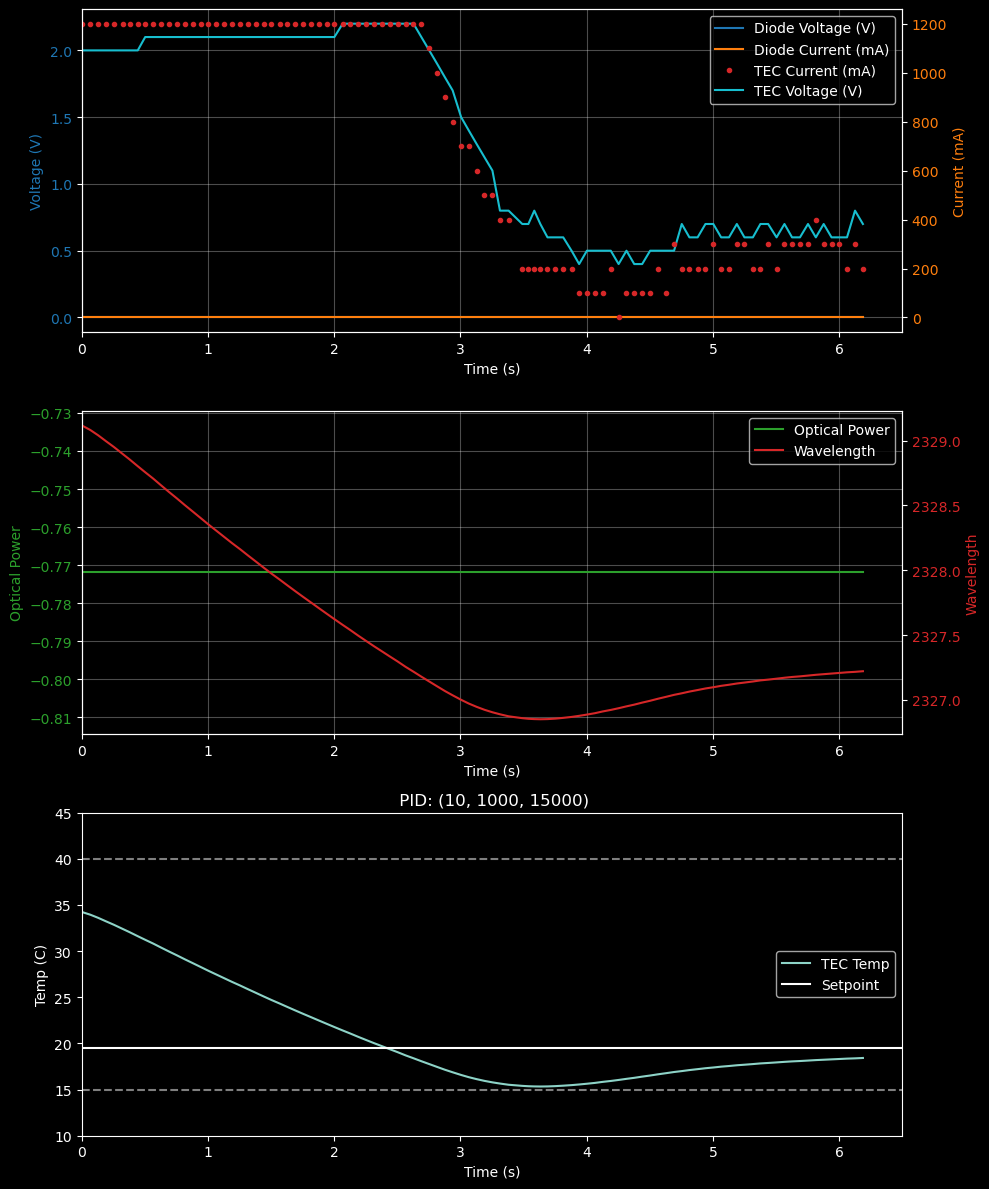

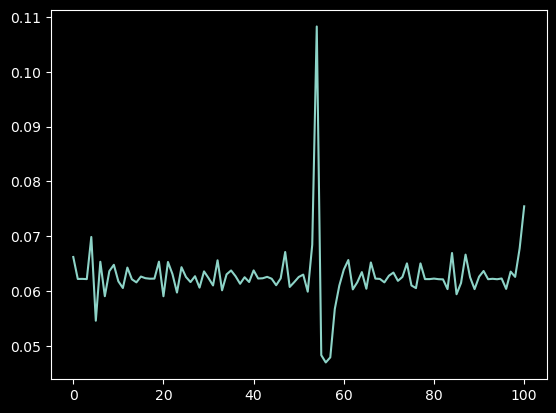

In [265]:
plot_tuning_data(lasers['2330'].laser_properties, data.get_data(), tset=t, pid=pid)
plt.plot(np.diff(data.get_data()['t_s']))

### Low-level access

In the event that direct device control is needed.

See `ait/maiman_modbus/utils/utils.py` for python constants of register names and `ait/maiman_modbus/config/modbus_config.yaml` for the register addresses.

Look at methods on `ModbusDevice` (`ait/maiman_modbus/device/modbus_device.py`) for functions.


```python
from maiman_modbus.communication import ModbusCommunication
import maiman_modbus.utils as maiman_regs
from maiman_modbus.device.modbus_device_model import ModbusDeviceModel
from maiman_modbus.config import DeviceConfig
from maiman_modbus.device.modbus_device import ModbusDevice

d = ModbusDevice(port=MODBUS_PORT, slave_address=modbus_address)
d.comm.send_command(d.model.get_register(STATE_OF_TEC_COMMAND), MODBUS_START_TEC_COMMAND_VALUE)

print(d.comm.receive_response(d.model.get_register(STATE_OF_TEC_COMMAND)))
```


In [56]:
from typing import Callable

class Bar:
    def __init__(self, name:str):
        self.name = name

    def core_method(self, *args):
        print(f"Core method of {repr(self)} name={self.name} called with args: {args}")


class Foo:
    def __init__(self, method:Callable, b:str):
        self.anothers_method = method
        self.b = b

    def call_anothers(self, arg):
        self.anothers_method(arg, self.b)

    def core_method(self, *args):
        print(f"Core method of {repr(self)} {self.b} called with args: {args}")


x = Bar('external')
y = Foo(x.core_method, 'bval, foo instance')

y.call_anothers('some arg to call_anothers')
y.core_method('some arg to y core method')
type(y.anothers_method)

Core method of <__main__.Bar object at 0x166b9bcd0> name=external called with args: ('some arg to call_anothers', 'bval, foo instance')
Core method of <__main__.Foo object at 0x166b99350> bval, foo instance called with args: ('some arg to y core method',)


method

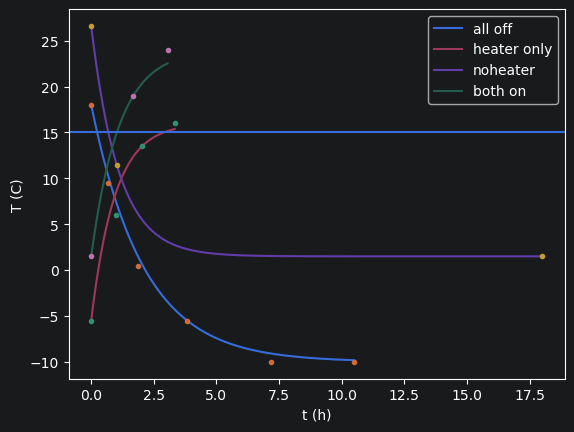

In [1]:
import matplotlib.pyplot as plt

series = {
    'all off': [(0, 18),
            (40, 9.5),
            (112, .5),
            (230, -5.5),
            (230+200, -10),(230+200+200, -10)],
    'heater only': [(0, -5.5),
               (60, 6),
               (122, 13.5),
               (200, 16)],
    'noheater': [(0, 26.6),
               (61, 11.5),
               (18 * 60, 1.5)],
    'both on': [
        (0, 1.5),
        (101, 19),
        (101 + 65 + 17, 24)
    ]
}

import numpy as np

for k, s in series.items():
    x, y = zip(*s)
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)

    X_ = np.linspace(x.min(), x.max(), 200)

    # Quick exponential interpolation for heating/cooling-like behavior:
    # y(t) = y_inf + (y0 - y_inf) * exp(-(t - t0)/tau)
    y0 = y[0]
    y_inf = y[-1]
    tau0 = max((x.max() - x.min()) / 2, 1.0)

    if len(x) >= 3:
        mid_idx = len(x) // 2
        t_mid = x[mid_idx]
        y_mid = y[mid_idx]
        denom = (y0 - y_inf)
        if denom != 0 and y_mid != y_inf:
            ratio = (y_mid - y_inf) / denom
            if ratio > 0:
                tau0 = max(-(t_mid - x.min()) / np.log(ratio), 1e-6)

    Y_ = y_inf + (y0 - y_inf) * np.exp(-(X_ - x.min()) / tau0)

    plt.plot(X_ / 60, Y_, label=k)
    plt.plot(x / 60, y, '.')
    plt.xlabel("t (h)")
    plt.ylabel("T (C)")
plt.axhline(15)
plt.legend()
plt.show()
